# F_S1 — 4-Class Scatter Image Generation

Generate 128×128 binary scatter images for CNN classification.

**4 classes**: linear, quadratic, sigmoid, other

- 1000 points per scatter
- Single-channel binary: 0=background, 1=point
- No axes, gridlines, or decorations

In [1]:
from __future__ import annotations

import json
import math
import time
import os
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

OUTPUT_DIR = Path('output/S1')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
N_PER_CASE = 1000
IMG_SIZE = 128
N_REPLICATES = 10
SIGNAL_VARIANCE_GRID_SIZE = 20_001

# 51 SNR levels: 50 log-spaced + inf
SNR_GRID = sorted(np.geomspace(0.01, 500, 50).tolist()) + [math.inf]

CLASS_NAMES = ['linear', 'quadratic', 'sigmoid', 'other']

# Human-annotated visibility boundaries (per config group)
# Will be set per-config based on shape difficulty
DEFAULT_CLEAR_SNR = 2.0
DEFAULT_THRESHOLD_SNR = 0.3

print(f'Points per scatter: {N_PER_CASE}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'SNR levels: {len(SNR_GRID)}')
print(f'Replicates: {N_REPLICATES}')
print(f'Classes: {CLASS_NAMES}')

Points per scatter: 1000
Image size: 128x128
SNR levels: 51
Replicates: 10
Classes: ['linear', 'quadratic', 'sigmoid', 'other']


## Shape Configurations

Each config = one parameterized function with a class label.

In [3]:
@dataclass(frozen=True)
class ShapeConfig:
    config_id: int
    class_name: str
    func_type: str
    variant_name: str
    variant_level: str
    params: dict
    clear_snr: float = 2.0
    threshold_snr: float = 0.3


def build_configs() -> list[ShapeConfig]:
    configs: list[ShapeConfig] = []
    _id = 0

    def add(cls, func, name, level, clear=2.0, thresh=0.3, **params):
        nonlocal _id
        _id += 1
        configs.append(ShapeConfig(
            config_id=_id, class_name=cls, func_type=func,
            variant_name=name, variant_level=level,
            params=params, clear_snr=clear, threshold_snr=thresh,
        ))

    # ════════════════════════════════════════
    #  LINEAR  (12 configs)
    # ════════════════════════════════════════
    for sign, tag in [(1, 'pos'), (-1, 'neg')]:
        add('linear', 'linear', f'{tag}_s0.3',  'mild',     slope=sign*0.3, intercept=0.0)
        add('linear', 'linear', f'{tag}_s1',    'standard', slope=sign*1.0, intercept=0.0)
        add('linear', 'linear', f'{tag}_s2',    'strong',   slope=sign*2.0, intercept=0.0)
        add('linear', 'linear', f'{tag}_s4',    'strong',   slope=sign*4.0, intercept=0.0)
        add('linear', 'linear', f'{tag}_s1_b02','standard', slope=sign*1.0, intercept=sign*0.2)
        add('linear', 'linear', f'{tag}_s2_b05','strong',   slope=sign*2.0, intercept=sign*0.5)

    # ════════════════════════════════════════
    #  QUADRATIC  (18 configs)
    # ════════════════════════════════════════
    # Power convex (p > 1)
    for sign, tag in [(1, 'pos'), (-1, 'neg')]:
        add('quadratic', 'power_convex', f'{tag}_p1.5', 'mild',     sign=sign, p=1.5)
        add('quadratic', 'power_convex', f'{tag}_p2.5', 'standard', sign=sign, p=2.5)
        add('quadratic', 'power_convex', f'{tag}_p4',   'strong',   sign=sign, p=4.0)

    # Power concave (0 < p < 1)
    for sign, tag in [(1, 'pos'), (-1, 'neg')]:
        add('quadratic', 'power_concave', f'{tag}_p0.7',  'mild',     sign=sign, p=0.7)
        add('quadratic', 'power_concave', f'{tag}_p0.5',  'standard', sign=sign, p=0.5)
        add('quadratic', 'power_concave', f'{tag}_p0.15', 'strong',   sign=sign, p=0.15)

    # U-shape / Inverted-U
    for sign, tag in [(1, 'valley'), (-1, 'peak')]:
        add('quadratic', 'parabola', f'{tag}_a1',  'mild',     sign=sign, a=1.0,  c=0.5)
        add('quadratic', 'parabola', f'{tag}_a4',  'standard', sign=sign, a=4.0,  c=0.5)
        add('quadratic', 'parabola', f'{tag}_a12', 'strong',   sign=sign, a=12.0, c=0.5)

    # ════════════════════════════════════════
    #  SIGMOID  (12 configs)
    # ════════════════════════════════════════
    # S-curve (logistic)
    for sign, tag in [(1, 'pos'), (-1, 'neg')]:
        add('sigmoid', 's_curve', f'{tag}_k6',  'mild',     sign=sign, k=6.0,  c=0.5, clear=15.0, thresh=7.0)
        add('sigmoid', 's_curve', f'{tag}_k10', 'standard', sign=sign, k=10.0, c=0.5, clear=12.0, thresh=5.0)
        add('sigmoid', 's_curve', f'{tag}_k20', 'strong',   sign=sign, k=20.0, c=0.5, clear=10.0, thresh=3.0)

    # Threshold (step)
    for sign, tag in [(1, 'pos'), (-1, 'neg')]:
        add('sigmoid', 'threshold', f'{tag}_d0.15', 'mild',     sign=sign, delta=0.15, c=0.5)
        add('sigmoid', 'threshold', f'{tag}_d0.08', 'standard', sign=sign, delta=0.08, c=0.5)
        add('sigmoid', 'threshold', f'{tag}_d0.02', 'strong',   sign=sign, delta=0.02, c=0.5)

    # ════════════════════════════════════════
    #  OTHER  (13 configs)
    # ════════════════════════════════════════
    # Spike / Inv-spike
    for sign, tag in [(1, 'up'), (-1, 'down')]:
        add('other', 'spike', f'{tag}_w0.08', 'mild',     sign=sign, width=0.08, c=0.5, clear=1.0, thresh=0.1)
        add('other', 'spike', f'{tag}_w0.03', 'standard', sign=sign, width=0.03, c=0.5, clear=1.0, thresh=0.1)
        add('other', 'spike', f'{tag}_w0.01', 'strong',   sign=sign, width=0.01, c=0.5, clear=1.0, thresh=0.1)

    # Two lines
    add('other', 'two_lines', 'narrow',   'mild',     m1=0.8, b1=0.0, m2=1.5, b2=0.0, clear=12.0, thresh=3.0)
    add('other', 'two_lines', 'medium',   'standard', m1=0.5, b1=0.0, m2=2.0, b2=0.0, clear=12.0, thresh=3.0)
    add('other', 'two_lines', 'wide',     'strong',   m1=0.2, b1=0.0, m2=3.0, b2=0.0, clear=12.0, thresh=3.0)

    # Line + parabola
    add('other', 'line_parab', 'close', 'mild',     m=1.5, b_line=0.0, a_para=0.8, h=0.5, peak=0.3, clear=12.0, thresh=3.0)
    add('other', 'line_parab', 'mid',   'standard', m=2.5, b_line=0.0, a_para=1.6, h=0.5, peak=0.4, clear=12.0, thresh=3.0)
    add('other', 'line_parab', 'far',   'strong',   m=3.5, b_line=0.0, a_para=3.0, h=0.5, peak=0.5, clear=12.0, thresh=3.0)

    # Null (pure noise)
    add('other', 'null', 'flat', 'standard', clear=999.0, thresh=999.0)

    return configs


configs = build_configs()
print(f'Total configs: {len(configs)}')
for cls in CLASS_NAMES:
    cls_cfgs = [c for c in configs if c.class_name == cls]
    func_types = sorted(set(c.func_type for c in cls_cfgs))
    joined = ", ".join(func_types)
    print(f'  {cls:<12s}: {len(cls_cfgs):>2} configs  ({joined})')

Total configs: 55
  linear      : 12 configs  (linear)
  quadratic   : 18 configs  (parabola, power_concave, power_convex)
  sigmoid     : 12 configs  (s_curve, threshold)
  other       : 13 configs  (line_parab, null, spike, two_lines)


## Signal Functions

In [4]:
def evaluate_signal(x, cfg, rng=None):
    x = np.asarray(x, dtype=float)
    p = cfg.params
    ft = cfg.func_type

    if ft == 'linear':
        return p['slope'] * x + p['intercept']

    if ft == 'power_convex':
        return p['sign'] * (x ** p['p'])

    if ft == 'power_concave':
        return p['sign'] * (x ** p['p'])

    if ft == 'parabola':
        return p['sign'] * p['a'] * (x - p['c']) ** 2

    if ft == 's_curve':
        return p['sign'] / (1.0 + np.exp(-p['k'] * (x - p['c'])))

    if ft == 'threshold':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['sign'] * t

    if ft == 'spike':
        return p['sign'] * np.exp(-np.abs(x - p['c']) / p['width'])

    if ft == 'two_lines':
        y0 = p['b1'] + p['m1'] * x
        y1 = p['b2'] + p['m2'] * x
        if rng is None:
            return 0.5 * (y0 + y1)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y0, y1)

    if ft == 'line_parab':
        y_line = p['b_line'] + p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return 0.5 * (y_line + y_para)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y_line, y_para)

    if ft == 'null':
        return np.zeros_like(x)

    raise ValueError(f'Unknown func_type: {ft}')


# Signal variance cache
_var_cache = {}

def signal_variance(cfg):
    if cfg.config_id not in _var_cache:
        x_grid = np.linspace(0.0, 1.0, SIGNAL_VARIANCE_GRID_SIZE)
        rng = np.random.default_rng(cfg.config_id)
        y = evaluate_signal(x_grid, cfg, rng=rng)
        _var_cache[cfg.config_id] = max(float(np.var(y, ddof=0)), 1e-30)
    return _var_cache[cfg.config_id]


def sigma_for_snr(cfg, snr):
    if math.isinf(snr):
        return 0.0
    if cfg.func_type == 'null':
        return 1.0
    return math.sqrt(signal_variance(cfg) / snr)

## Image Rendering

Convert (x, y) scatter to 128×128 binary image.
Min-max normalize y, flip vertical, single pixel per point.

In [5]:
def scatter_to_image(x, y, size=IMG_SIZE):
    img = np.zeros((size, size), dtype=np.uint8)

    # Normalize x to [0, 1] (already is, but clip for safety)
    x_n = np.clip(x, 0.0, 1.0)

    # Normalize y to [0, 1] via min-max
    y_min, y_max = y.min(), y.max()
    if y_max - y_min < 1e-12:
        y_n = np.full_like(y, 0.5)
    else:
        y_n = (y - y_min) / (y_max - y_min)

    # Map to pixel coords (flip y so high values are at top)
    px = np.clip((x_n * (size - 1)).astype(int), 0, size - 1)
    py = np.clip(((1.0 - y_n) * (size - 1)).astype(int), 0, size - 1)

    img[py, px] = 1
    return img

## Build Cases & Generate Images

In [6]:
# Build case metadata
rows = []
cfg_map = {}

for cfg in configs:
    cfg_map[cfg.config_id] = cfg
    for snr in SNR_GRID:
        for rep in range(N_REPLICATES):
            rows.append({
                'case_id': len(rows) + 1,
                'config_id': cfg.config_id,
                'class_name': cfg.class_name,
                'func_type': cfg.func_type,
                'variant_name': cfg.variant_name,
                'variant_level': cfg.variant_level,
                'params_json': json.dumps(cfg.params, sort_keys=True),
                'snr': 'inf' if math.isinf(snr) else float(snr),
                'replicate': rep,
                'n': N_PER_CASE,
                'clear_snr': cfg.clear_snr,
                'threshold_snr': cfg.threshold_snr,
            })

cases = pd.DataFrame(rows)
cases['snr_float'] = cases['snr'].apply(lambda v: math.inf if str(v) == 'inf' else float(v))

print(f'Total cases: {len(cases):,}')
print(f'\nPer class:')
print(cases.groupby('class_name')['case_id'].count().reindex(CLASS_NAMES))
print(f'\nPer func_type:')
print(cases.groupby(['class_name', 'func_type'])['case_id'].count())

Total cases: 28,050

Per class:
class_name
linear       6120
quadratic    9180
sigmoid      6120
other        6630
Name: case_id, dtype: int64

Per func_type:
class_name  func_type    
linear      linear           6120
other       line_parab       1530
            null              510
            spike            3060
            two_lines        1530
quadratic   parabola         3060
            power_concave    3060
            power_convex     3060
sigmoid     s_curve          3060
            threshold        3060
Name: case_id, dtype: int64


In [7]:
n_total = len(cases)
images = np.empty((n_total, IMG_SIZE, IMG_SIZE), dtype=np.uint8)

t0 = time.time()
for idx in range(n_total):
    row = cases.iloc[idx]
    cfg = cfg_map[int(row['config_id'])]

    seed = int(row['case_id']) * 1000 + int(row['replicate'])
    rng = np.random.default_rng(seed)

    # Generate scatter points
    x = rng.uniform(0.0, 1.0, size=N_PER_CASE)
    y_signal = evaluate_signal(x, cfg, rng=rng)

    snr = math.inf if str(row['snr']) == 'inf' else float(row['snr'])
    sigma = sigma_for_snr(cfg, snr)
    if sigma > 0:
        y = y_signal + rng.normal(0.0, sigma, size=N_PER_CASE)
    else:
        y = y_signal.copy()

    images[idx] = scatter_to_image(x.astype(np.float32), y.astype(np.float32))

    if (idx + 1) % 5000 == 0:
        elapsed = time.time() - t0
        rate = (idx + 1) / elapsed
        eta = (n_total - idx - 1) / rate
        print(f'  {idx+1:>7,}/{n_total:,}  ({rate:.0f}/s, ETA {eta:.0f}s)')

elapsed = time.time() - t0
print(f'\nGenerated {n_total:,} images in {elapsed:.0f}s')
print(f'Image array: {images.shape}, dtype={images.dtype}')
print(f'Mean pixels per image: {images.sum(axis=(1,2)).mean():.0f} / {IMG_SIZE*IMG_SIZE}')

    5,000/28,050  (11904/s, ETA 2s)
   10,000/28,050  (12127/s, ETA 1s)
   15,000/28,050  (12165/s, ETA 1s)
   20,000/28,050  (11909/s, ETA 1s)
   25,000/28,050  (12035/s, ETA 0s)

Generated 28,050 images in 2s
Image array: (28050, 128, 128), dtype=uint8
Mean pixels per image: 855 / 16384


In [8]:
cases.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
np.savez_compressed(OUTPUT_DIR / 'images.npz', images=images)

size_mb = (OUTPUT_DIR / 'images.npz').stat().st_size / 1e6
print(f'Saved cases.csv ({len(cases):,} rows)')
print(f'Saved images.npz  {images.shape}  {size_mb:.1f} MB')

Saved cases.csv (28,050 rows)
Saved images.npz  (28050, 128, 128)  23.2 MB


## Visibility Zones

In [9]:
def assign_zone(row):
    snr = row['snr_float']
    if snr >= row['clear_snr']:
        return 'visible'
    elif snr > row['threshold_snr']:
        return 'fuzzy'
    else:
        return 'invisible'

cases['zone'] = cases.apply(assign_zone, axis=1)

zone_counts = cases.groupby(['zone', 'class_name'])['case_id'].count().unstack(fill_value=0)
zone_counts = zone_counts.reindex(columns=CLASS_NAMES)
print(zone_counts)
print(f'\nVisible: {(cases["zone"]=="visible").sum():,}')
print(f'Fuzzy:   {(cases["zone"]=="fuzzy").sum():,}')
print(f'Invisible: {(cases["zone"]=="invisible").sum():,}')

class_name  linear  quadratic  sigmoid  other
zone                                         
fuzzy          960       1440      760   1020
invisible     1920       2880     2660   2720
visible       3240       4860     2700   2890

Visible: 13,690
Fuzzy:   4,180
Invisible: 10,180


## Preview

Show sample images for each class × variant level at SNR=inf and SNR=5.

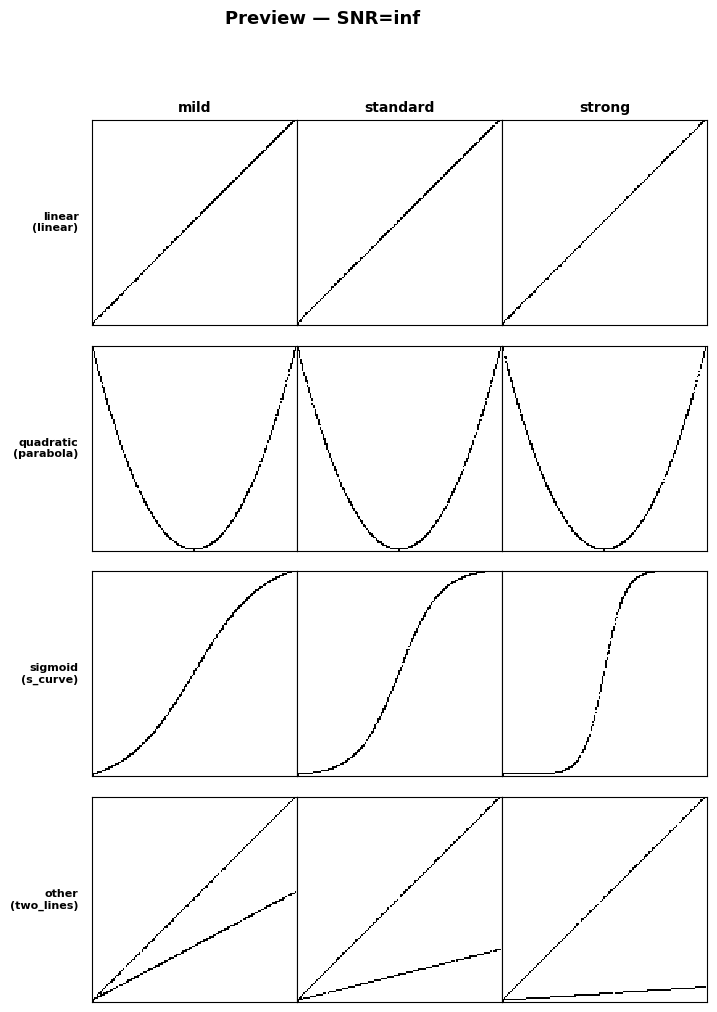

Saved preview_snr_inf.png


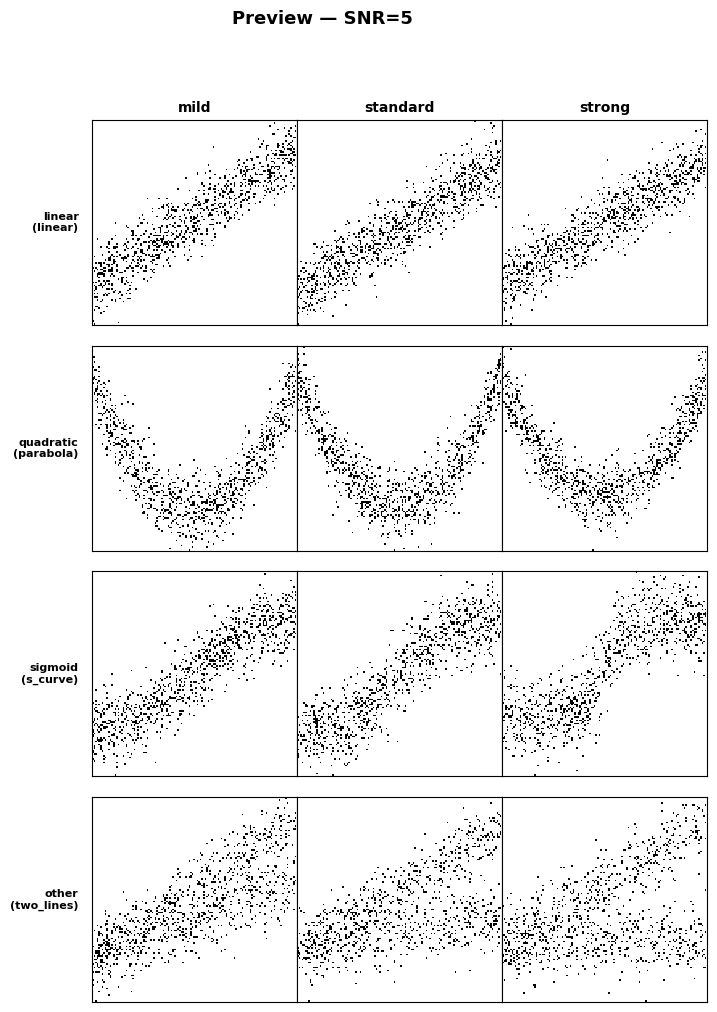

Saved preview_snr_5.png


In [10]:
for snr_target in [math.inf, 5.0]:
    snr_label = 'inf' if math.isinf(snr_target) else f'{snr_target:.0f}'

    # Pick one func_type per class for preview
    preview_funcs = {
        'linear': 'linear',
        'quadratic': 'parabola',
        'sigmoid': 's_curve',
        'other': 'two_lines',
    }

    fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(8, 2.5 * len(CLASS_NAMES)))
    fig.suptitle(f'Preview — SNR={snr_label}', fontsize=13, fontweight='bold', y=1.01)

    for row_i, cls in enumerate(CLASS_NAMES):
        ft = preview_funcs[cls]
        for col_i, vlevel in enumerate(['mild', 'standard', 'strong']):
            ax = axes[row_i, col_i]

            match = cases[
                (cases['class_name'] == cls) &
                (cases['func_type'] == ft) &
                (cases['variant_level'] == vlevel) &
                (cases['replicate'] == 0)
            ]
            if math.isinf(snr_target):
                match = match[match['snr'].astype(str) == 'inf']
            else:
                match = match[np.isfinite(match['snr_float'])]
                if len(match) > 0:
                    best = (match['snr_float'] - snr_target).abs().idxmin()
                    match = match.loc[[best]]

            if len(match) > 0:
                idx = match.index[0]
                ax.imshow(images[idx], cmap='gray_r', interpolation='nearest',
                          vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if row_i == 0:
                ax.set_title(vlevel, fontsize=10, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(f'{cls}\n({ft})', fontsize=8, fontweight='bold',
                              rotation=0, ha='right', va='center', labelpad=10)

    plt.tight_layout(rect=[0.1, 0, 1, 0.97])
    plt.savefig(OUTPUT_DIR / f'preview_snr_{snr_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved preview_snr_{snr_label}.png')

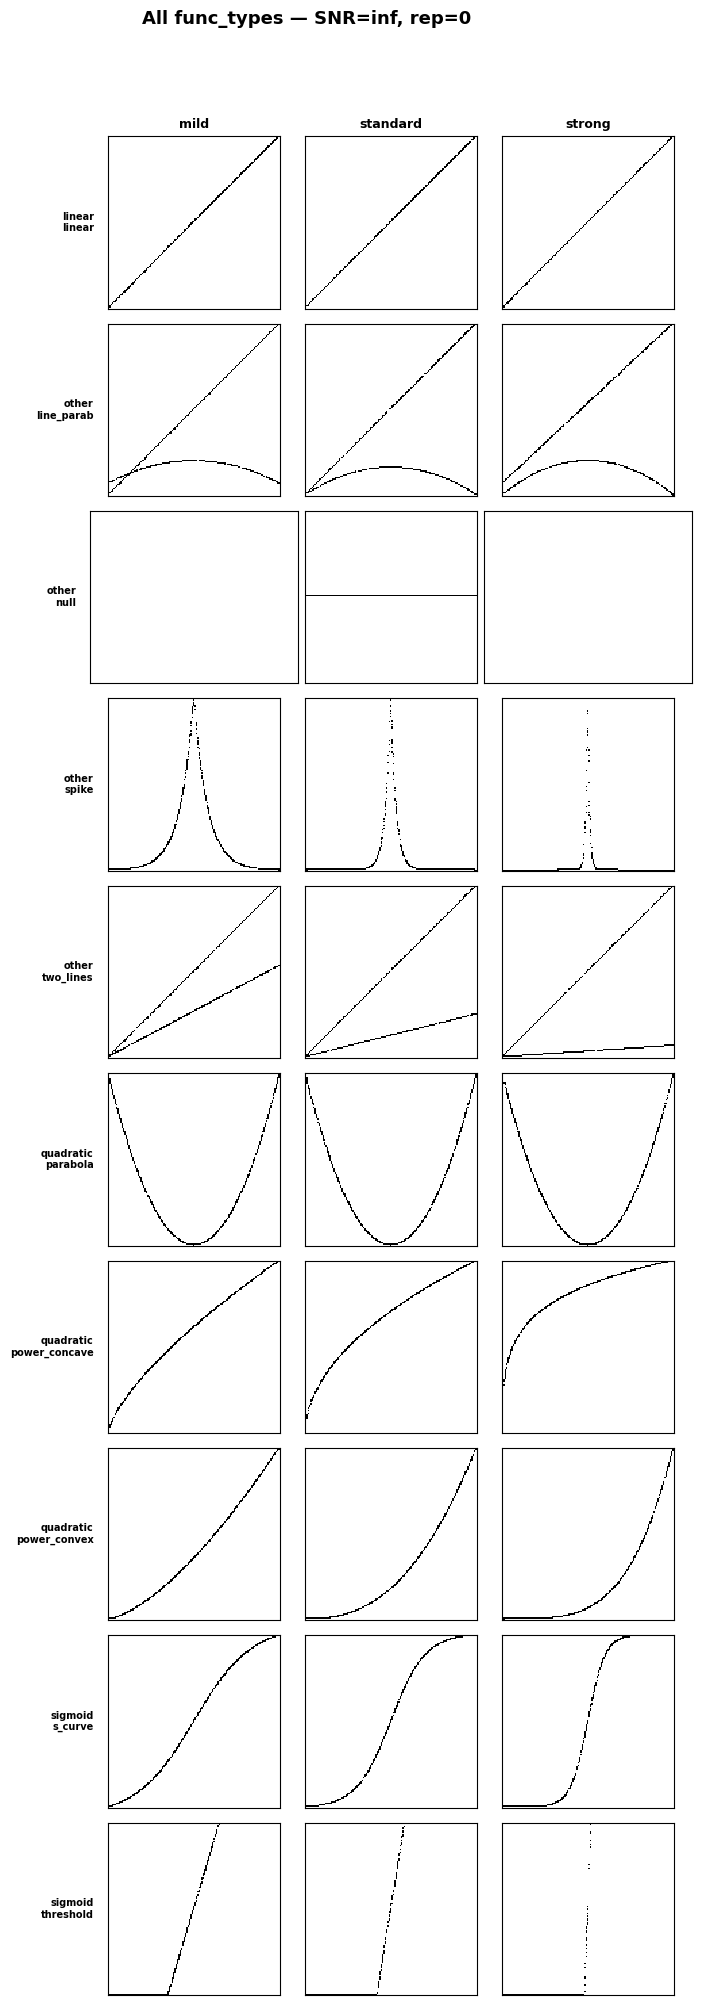

In [11]:
# Show ALL func_types at SNR=inf
all_func_types = cases.groupby(['class_name', 'func_type']).first().reset_index()
all_func_types = all_func_types.sort_values(['class_name', 'func_type'])

n_funcs = len(all_func_types)
fig, axes = plt.subplots(n_funcs, 3, figsize=(8, 2 * n_funcs))
fig.suptitle('All func_types — SNR=inf, rep=0', fontsize=13, fontweight='bold', y=1.0)

for row_i, (_, row) in enumerate(all_func_types.iterrows()):
    cls, ft = row['class_name'], row['func_type']
    for col_i, vlevel in enumerate(['mild', 'standard', 'strong']):
        ax = axes[row_i, col_i]
        match = cases[
            (cases['class_name'] == cls) &
            (cases['func_type'] == ft) &
            (cases['variant_level'] == vlevel) &
            (cases['replicate'] == 0) &
            (cases['snr'].astype(str) == 'inf')
        ]
        if len(match) > 0:
            ax.imshow(images[match.index[0]], cmap='gray_r',
                      interpolation='nearest', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0:
            ax.set_title(vlevel, fontsize=9, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{cls}\n{ft}', fontsize=7, fontweight='bold',
                          rotation=0, ha='right', va='center', labelpad=10)

plt.tight_layout(rect=[0.12, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'preview_all_funcs.png', dpi=150, bbox_inches='tight')
plt.show()